<a href="https://colab.research.google.com/github/cmvigneswaranaero-gif/AC_PERFROMANCE_WITH_ML/blob/main/PERFORMANCE_LOGISTIC__REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression Recap

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics

In [12]:
#Import the Dataset: AoA vs stall.csv
aircraft=pd.read_csv("https://raw.githubusercontent.com/cmvigneswaranaero-gif/AC_PERFROMANCE_WITH_ML/refs/heads/main/linear%20vs%20logistic%20_Product_sales.csv")

In [24]:
import sklearn as sk
from sklearn import linear_model
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(aircraft[["AOA"]], aircraft[["STALL_OR_NOSTALL"]])


LinearRegression()

In [14]:
print("intercept",lr.intercept_)
print("Co-efficient",lr.coef_)

intercept [-0.17493853]
Co-efficient [[0.02102409]]


In [41]:
#If AOA is 105, then,  will AIRCRFAT STALL?
predict1 = lr.predict([[4]])
print(predict1)

# THE ABOVE CAN BE WRITE IN FOLLOWING WAY
d1=pd.DataFrame({"AOA":[4]})
predict1=lr.predict(d1)
print(predict1)


[-0.09084219]
[-0.09084219]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [40]:
#If AOA is 105, then,  will AIRCRFAT STALL?
predict2 = lr.predict([[105]])
print(predict2)

[2.03259042]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [43]:

# Predict values
y_pred = lr.predict(aircraft[["AOA"]])

# Calculate R²
r2 = r2_score(aircraft["STALL_OR_NOSTALL"], y_pred)
print("R-squared:", r2)                           # THOUGH ITS SHOWING GOOD R2, BUT ITS INVALID.

R-squared: 0.8496458586530549


## Drawing Linear Regression line

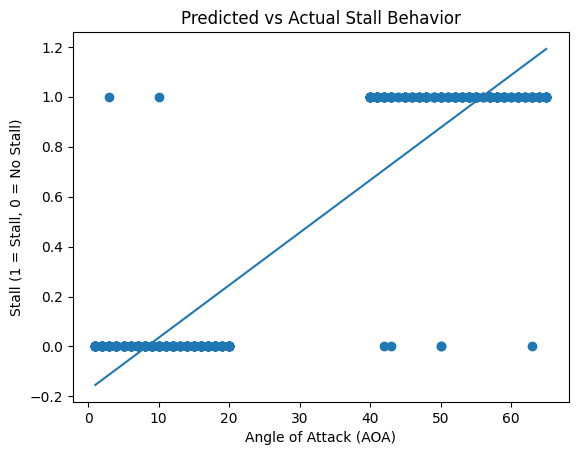

In [28]:
# 1. Fit Linear Regression Model
lr = LinearRegression()
lr.fit(aircraft[["AOA"]], aircraft["STALL_OR_NOSTALL"])

# 2. Add predicted stall directly inside aircraft df
aircraft["PRED_STALL"] = lr.predict(aircraft[["AOA"]])

# 3. Sort for smooth line in graph: SORT is to prevent the LINE PLOT from zig-zagging (random order)
aircraft = aircraft.sort_values("AOA")

# 4. Plot Actual vs Predicted
plt.scatter(aircraft["AOA"], aircraft["STALL_OR_NOSTALL"])     # Actual stall
plt.plot(aircraft["AOA"], aircraft["PRED_STALL"])              # Predicted stall

# 5. Labels
plt.title("Predicted vs Actual Stall Behavior")
plt.xlabel("Angle of Attack (AOA)")
plt.ylabel("Stall (1 = Stall, 0 = No Stall)")

plt.show()
# Scatter plot = Actual AoA vs Actual Stall
# Line plot = Actual AoA vs Predicted Stall


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()
logistic.fit(sales[["Age"]],sales["Bought"])

LogisticRegression()

In [ ]:
print("Intercept", logistic.intercept_)
print("Coefficient", logistic.coef_)

Intercept [-6.90722429]
Coefficient [[0.21777169]]


In [ ]:
#A 4 years old customer, will he buy the product?

predict_age1=logistic.predict(d1)
print(predict_age1)

[0]


In [ ]:
#If Age is 105 then will that customer buy the product?

predict_age2=logistic.predict(d2)
print(predict_age2)

[1]


## Drawing Logistic Regression line

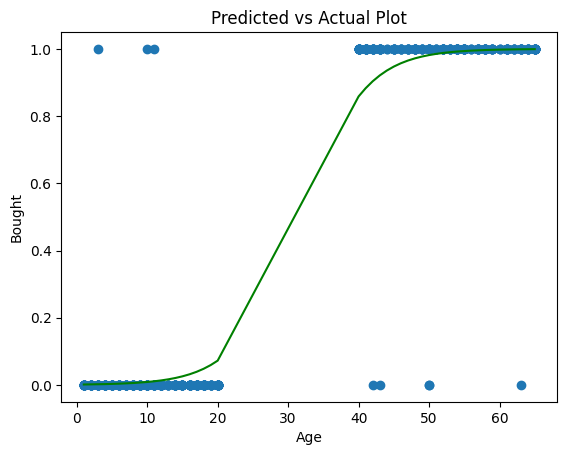

In [ ]:
new_data=sales.drop(["Bought"], axis=1)
#Pass the variables to get the predicted values. Add actual values in a new column
new_data["pred_values"]= logistic.predict_proba(new_data)[:,1]
new_data["Actual"]=sales["Bought"]

#Sort the data and draw the graph
new_data=new_data.sort_values(["pred_values"])
plt.scatter(new_data["Age"], new_data["Actual"])
plt.plot(new_data["Age"], new_data["pred_values"], color='green')
#Add lables and title
plt.title('Predicted vs Actual Plot')
plt.xlabel('Age')
plt.ylabel('Bought')
plt.show()

# Multiple Logistic Regression

In [ ]:
Fiber=pd.read_csv("https://raw.githubusercontent.com/cmvigneswaranaero-gif/ML-DL/refs/heads/main/logistic%20_regression.csv")


In [ ]:
Fiber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   active_cust                 100000 non-null  int64
 1   income                      100000 non-null  int64
 2   months_on_network           100000 non-null  int64
 3   Num_complaints              100000 non-null  int64
 4   number_plan_changes         100000 non-null  int64
 5   relocated                   100000 non-null  int64
 6   monthly_bill                100000 non-null  int64
 7   technical_issues_per_month  100000 non-null  int64
 8   Speed_test_result           100000 non-null  int64
dtypes: int64(9)
memory usage: 6.9 MB


In [ ]:
logistic1= LogisticRegression()
###fitting logistic regression for active customer on rest of the variables#######
logistic1.fit(Fiber[["income"]+['months_on_network']+['Num_complaints']+['number_plan_changes']+['relocated']+['monthly_bill']+['technical_issues_per_month']+['Speed_test_result']],Fiber[['active_cust']])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
print("Intercept", logistic1.intercept_)
print("Coefficients", logistic1.coef_)

Intercept [-0.01100601]
Coefficients [[ 3.71249380e-05  2.55962690e-02  7.37975743e-01 -2.63294380e-01
  -1.42452436e-01  7.87918595e-05 -2.64241712e-01 -7.63137265e-02]]


# Confusion Matrix & Accuracy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [ ]:
predict1=logistic1.predict(Fiber[["income"]+['months_on_network']+['Num_complaints']+['number_plan_changes']+['relocated']+['monthly_bill']+['technical_issues_per_month']+['Speed_test_result']])
print("Predicted y values:")
print(predict1)

cm1 = confusion_matrix(Fiber[['active_cust']],predict1)
print("Confusion Matrix:\n", cm1)

Predicted y values:
[1 1 0 ... 1 1 1]
Confusion Matrix:
 [[33852  8289]
 [ 6143 51716]]


In [ ]:
print("col sums", sum(cm1))
total1=sum(sum(cm1))
print("Total", total1)


col sums [39995 60005]
Total 100000


In [ ]:
accuracy1=(cm1[0,0]+cm1[1,1])/total1
accuracy1

np.float64(0.85568)

# Multicollinearity

In [ ]:
import statsmodels.formula.api as sm

def vif_cal(input_data, dependent_col):
    x_vars=input_data.drop([dependent_col], axis=1)
    xvar_names=x_vars.columns
    for i in range(0,xvar_names.shape[0]):
        y=x_vars[xvar_names[i]]
        x=x_vars[xvar_names.drop(xvar_names[i])]
        rsq=sm.ols(formula="y~x", data=x_vars).fit().rsquared
        vif=round(1/(1-rsq),2)
        print (xvar_names[i], " VIF = " , vif)

In [ ]:
vif_cal(input_data=Fiber, dependent_col="active_cust")

income  VIF =  1.02
months_on_network  VIF =  1.04
Num_complaints  VIF =  1.17
number_plan_changes  VIF =  11.98
relocated  VIF =  1.61
monthly_bill  VIF =  1.0
technical_issues_per_month  VIF =  11.44
Speed_test_result  VIF =  1.14


In [ ]:
#Drop the variable with highest VIF
vif_cal(input_data=Fiber.drop("number_plan_changes", axis=1), dependent_col="active_cust")

income  VIF =  1.02
months_on_network  VIF =  1.04
Num_complaints  VIF =  1.17
relocated  VIF =  1.55
monthly_bill  VIF =  1.0
technical_issues_per_month  VIF =  1.49
Speed_test_result  VIF =  1.14


# Individual Impact of Variables

In [ ]:
import statsmodels.api as sm
m1=sm.Logit(Fiber['active_cust'],Fiber[["income"]+['months_on_network']+['Num_complaints']+['relocated']+['monthly_bill']+['technical_issues_per_month']+['Speed_test_result']])
m1.fit()
print(m1.fit().summary())

Optimization terminated successfully.
         Current function value: 0.297056
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.297056
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            active_cust   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99993
Method:                           MLE   Df Model:                            6
Date:                Mon, 01 Sep 2025   Pseudo R-squ.:                  0.5636
Time:                        08:47:25   Log-Likelihood:                -29706.
converged:                       True   LL-Null:                       -68074.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

In [ ]:
m1=sm.Logit(Fiber['active_cust'],Fiber[["income"]+['months_on_network']+['Num_complaints']+['relocated']+['technical_issues_per_month']+['Speed_test_result']])
m1.fit()
print(m1.fit().summary())

Optimization terminated successfully.
         Current function value: 0.297061
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.297061
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            active_cust   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99994
Method:                           MLE   Df Model:                            5
Date:                Mon, 01 Sep 2025   Pseudo R-squ.:                  0.5636
Time:                        05:41:12   Log-Likelihood:                -29706.
converged:                       True   LL-Null:                       -68074.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

# Rank Ordering of the impactful variables

In [ ]:
m1=sm.Logit(Fiber['active_cust'],Fiber[["income"]+['months_on_network']+['Num_complaints']+['relocated']+['technical_issues_per_month']+['Speed_test_result']])
m1.fit()
print(m1.fit().summary())

Optimization terminated successfully.
         Current function value: 0.297061
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.297061
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            active_cust   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99994
Method:                           MLE   Df Model:                            5
Date:                Mon, 01 Sep 2025   Pseudo R-squ.:                  0.5636
Time:                        08:47:31   Log-Likelihood:                -29706.
converged:                       True   LL-Null:                       -68074.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------